# Visualization

Trong bài tập này, bạn sẽ được rèn luyện kĩ năng trực quan hóa. Trực quan hóa ngoài việc hỗ  trợ trong khâu tiền xử lí dữ liệu, còn giúp bạn phân tích và rút ra được các thông tin có ý nghĩa từ dữ liệu

**Tập dữ liệu** được sử dụng được lấy từ trang batdongsan.com.vn

In [1]:
#Import các thư viện cần thiết

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings(action='once')
import random
import math

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
# cd /content/drive/MyDrive/Preprocessing_practice/2.Assignment/Batdongsan.com.vn

In [4]:
#Load dữ liệu từ file
newdf = pd.read_csv("batdongsan.com.vn.csv", dtype = {"month": "string" , "id" : "string"})
print("DONE")

DONE


In [5]:
newdf.columns

Index(['id', 'month', 'project', 'investor', 'square', 'bedrooms', 'bathrooms',
       'direction', 'balcony', 'district', 'ward', 'price'],
      dtype='object')

In [6]:
# Xem 5 hàng dữ liệu đầu tiên, các thông tin ban đầu: df.info(), df.describe(), ...
# Code ở đây:
newdf.head()

,id,month,project,investor,square,bedrooms,bathrooms,direction,balcony,district,ward,price
0,28086120,12,Vinhomes Smart City Đại Mỗ,Tập đoàn Vingroup,60.0,3.0,1.0,Đông-Nam,Tây-Bắc,nam tu liem,dai mo,1560.0
1,28088954,12,Goldmark City,Công ty TNHH Thương mại - Quảng cáo - Xây dựng...,121.0,3.0,2.0,NaN,NaN,bac tu liem,phu dien,3300.0
2,28097966,12,Chung cư IEC Tứ Hiệp,NaN,70.0,2.0,2.0,Tây-Bắc,Đông-Nam,thanh tri,tu hiep,1106.0
3,27895887,12,Vinhomes D'Capitale,Tân Hoàng Minh Group,39.0,1.0,1.0,Đông-Nam,Đông-Nam,cau giay,trung hoa,1500.0
4,28056031,12,The Zen Residence,Công ty TNHH Gamuda Land Việt Nam,97.0,3.0,2.0,NaN,NaN,hoang mai,hoang liet,2900.0


Đưa ra các câu lệnh để thực hiện các yêu cầu sau:

1. Minh họa boxblot của các trường số như price, bedrooms, square, ...

* Gợi ý: sns.boxplot(data_field)

c:\Users\Thach\anaconda3\envs\FDM\lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


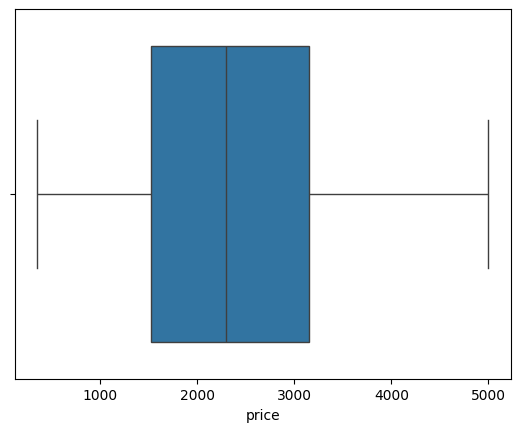

In [7]:
#Code for 'price' field
sns.boxplot(x=newdf['price'])
plt.show()

c:\Users\Thach\anaconda3\envs\FDM\lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


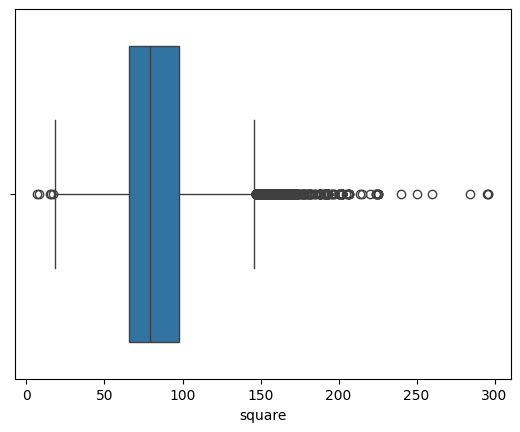

In [8]:
#Code for 'square' field
sns.boxplot(x=newdf['square'])
plt.show()

c:\Users\Thach\anaconda3\envs\FDM\lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


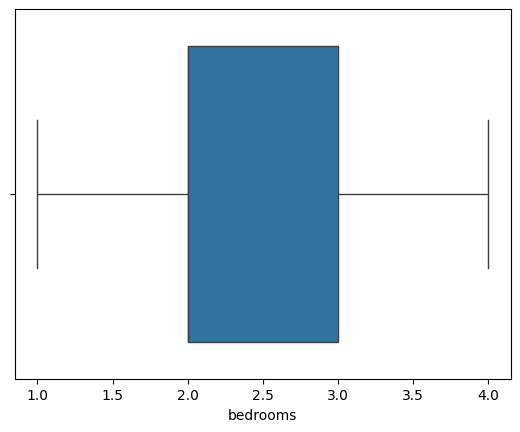

In [9]:
#Code for 'bedrooms' field
sns.boxplot(x=newdf['bedrooms'])
plt.show()

c:\Users\Thach\anaconda3\envs\FDM\lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


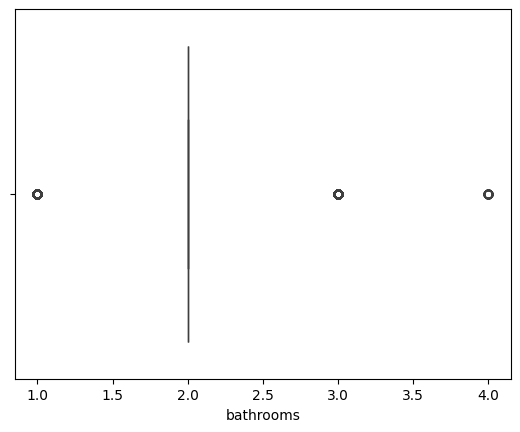

In [10]:
#Code for 'bathrooms' field
sns.boxplot(x=newdf['bathrooms'])
plt.show()

2. Cho đoạn code minh họa Biểu đồ thể hiện số bài đăng theo tháng của năm 2020. Hãy thực hiện các yêu cầu cho các câu hỏi dưới đây:

C:\Users\Thach\AppData\Local\Temp\ipykernel_16008\1920162332.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df1['month'], rotation=60, horizontalalignment= 'right')


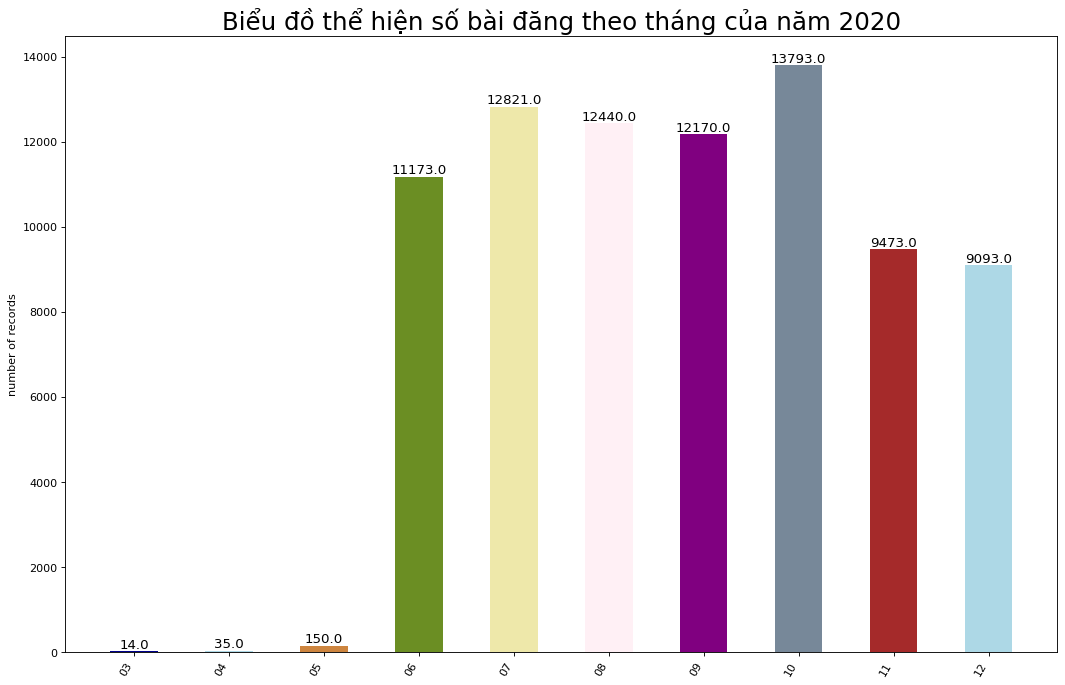

In [11]:
df1 = newdf.groupby('month').size().reset_index(name='number of records')
n = df1['month'].unique().__len__()+1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)

plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df1['month'], df1['number of records'], color=c, width=.5)
for i, val in enumerate(df1['number of records'].values):
    plt.text(i, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

plt.gca().set_xticklabels(df1['month'], rotation=60, horizontalalignment= 'right')
plt.title("Biểu đồ thể hiện số bài đăng theo tháng của năm 2020", fontsize=22)
plt.ylabel('number of records')
plt.show()

* Biểu đồ thể hiện giá nhà đất trung bình theo tháng (VND/m2)

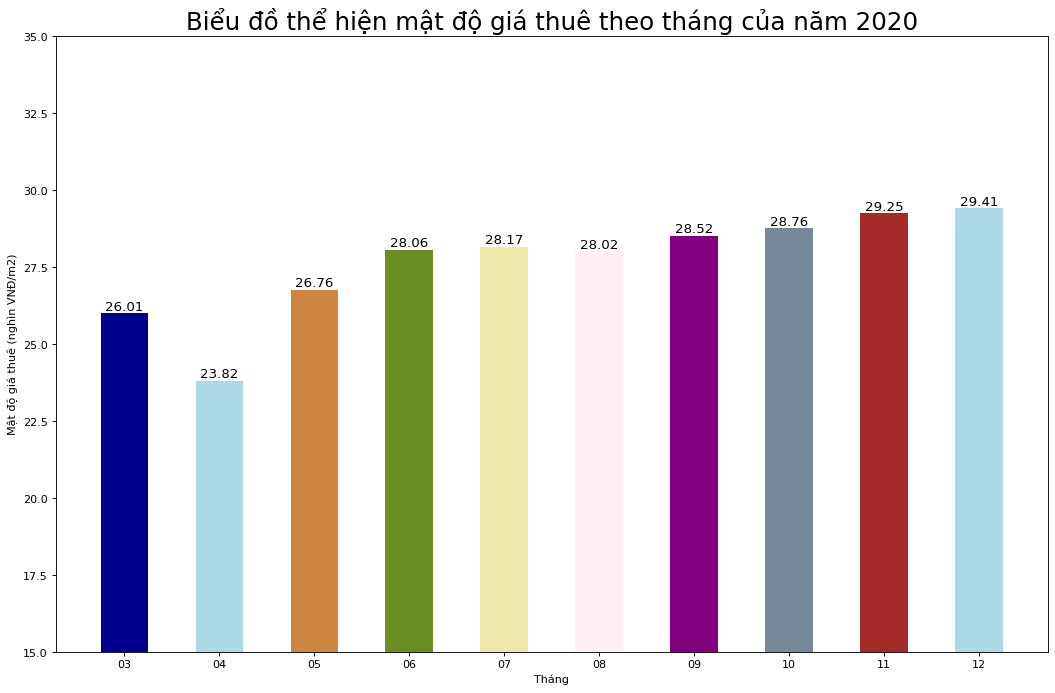

In [104]:
#Code ở đây
df1 = newdf.copy()
df1['density'] = df1['price'] / df1['square']
df2 = df1.groupby('month')['density'].mean().round(2).reset_index(name='avg_density')

n = df2['month'].unique().__len__()+1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)


plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df2['month'], df2['avg_density'], color=c, width=.5)
for i, val in enumerate(df2['avg_density'].values):
    plt.text(i, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

plt.xlabel('Tháng')
plt.title("Biểu đồ thể hiện mật độ giá thuê theo tháng của năm 2020", fontsize=22)
plt.ylabel('Mật độ giá thuê (nghìn VNĐ/m2)')
plt.ylim(15,35)
plt.show()

* Biểu đồ mật độ giá nhà của tháng 4 và tháng 12 (VND/m2)

<Figure size 1280x800 with 0 Axes>

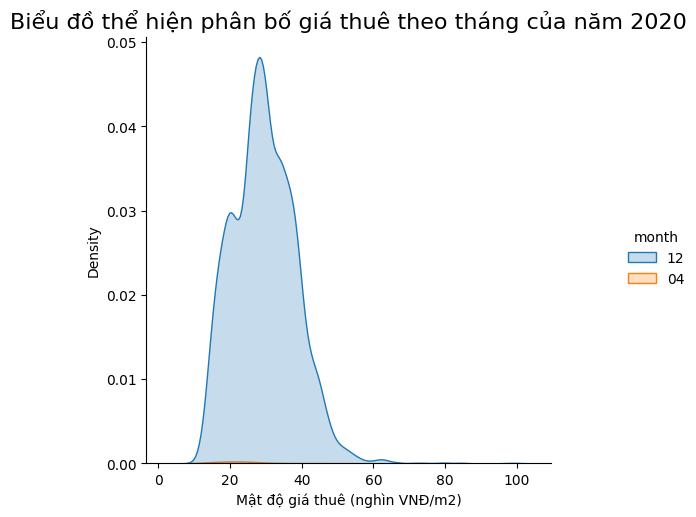

In [88]:
#Gọi ý: sns.displot()
df_plot = df1[df1['month'].isin(['04', '12'])]
plt.figure(figsize=(16,10), dpi= 80)
sns.displot(x = df_plot['density'], hue=df_plot['month'], kind="kde", fill=True)
plt.title("Biểu đồ thể hiện phân bố giá thuê theo tháng của năm 2020", fontsize=16)
plt.xlabel('Mật độ giá thuê (nghìn VNĐ/m2)')
plt.show()

C:\Users\Thach\AppData\Local\Temp\ipykernel_16008\69372113.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1.loc[df1['month'] == '12', "density"], color="dodgerblue", label="Thang 12", hist_kws={'alpha':.7}, kde_kws={'linewidth':3})
C:\Users\Thach\AppData\Local\Temp\ipykernel_16008\69372113.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwa

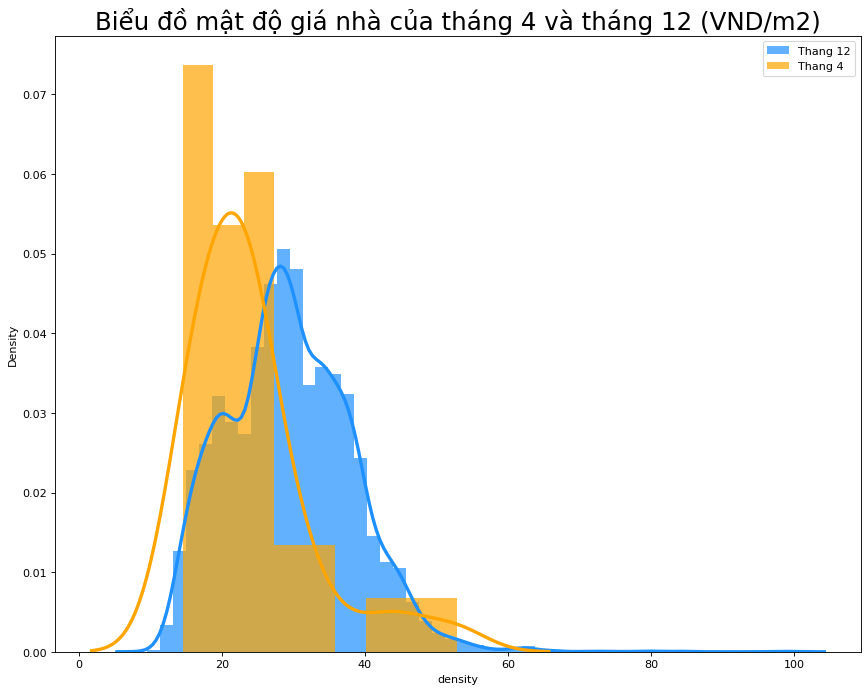

In [89]:
plt.figure(figsize=(13,10), dpi= 80)
sns.distplot(df1.loc[df1['month'] == '12', "density"], color="dodgerblue", label="Thang 12", hist_kws={'alpha':.7}, kde_kws={'linewidth':3})
sns.distplot(df1.loc[df1['month'] == '04', "density"], color="orange", label="Thang 4", hist_kws={'alpha':.7}, kde_kws={'linewidth':3})
plt.title('Biểu đồ mật độ giá nhà của tháng 4 và tháng 12 (VND/m2)', fontsize=22)
plt.legend()
plt.show()

* Số lượng bất động sản phân theo số lượng bedrooms

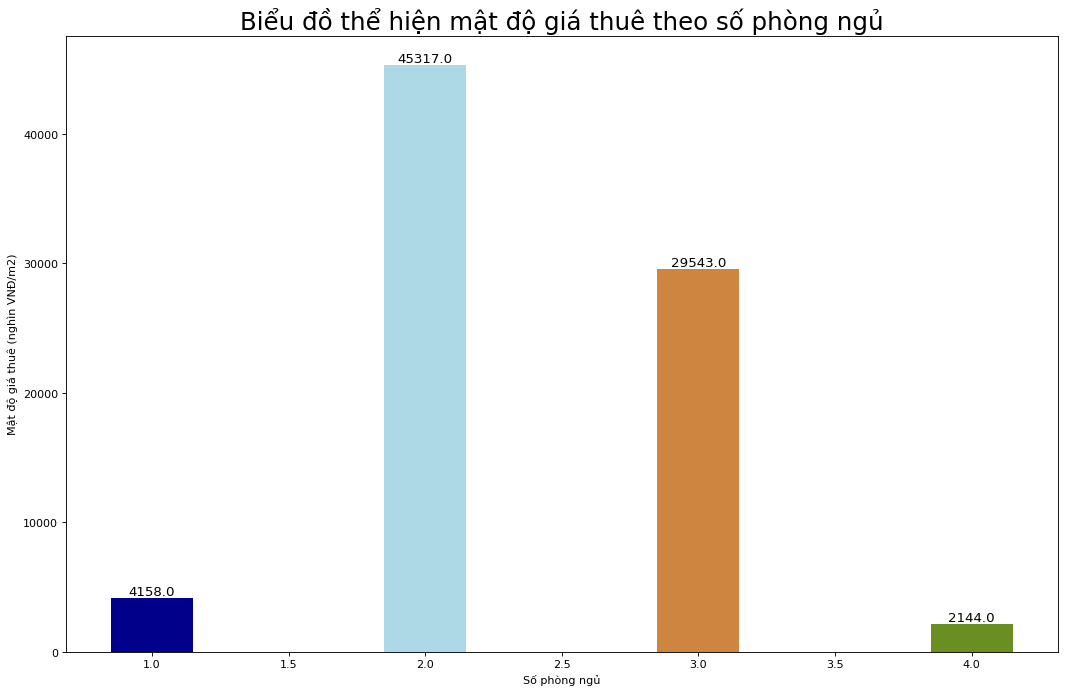

In [118]:
df3 = df1.groupby('bedrooms').size().reset_index(name='count')

all_colors = list(plt.cm.colors.cnames.keys())

plt.figure(figsize=(16,10), dpi= 80)
plt.bar(x = df3['bedrooms'], height = df3['count'], color=c, width=.3)
plt.xlabel('Số phòng ngủ')
plt.ylabel('Mật độ giá thuê (nghìn VNĐ/m2)')
plt.title("Biểu đồ thể hiện mật độ giá thuê theo số phòng ngủ", fontsize=22)
for i, val in enumerate(df3['count'].values):
    plt.text(i+1, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

* Giá bất động sản trung bình theo số lượng bedrooms

   bedrooms  count  density
0       1.0   4158    30.21
1       2.0  45317    27.82
2       3.0  29543    29.57
3       4.0   2144    26.50


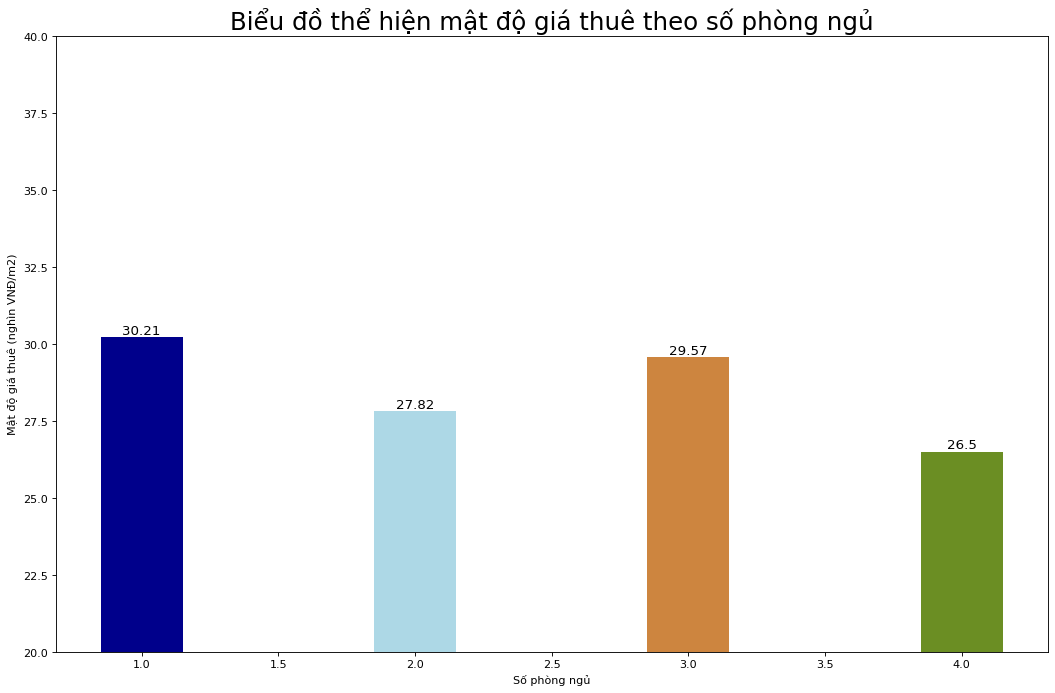

In [133]:
# Code ở đây
df3 = df1.groupby('bedrooms').size().reset_index(name='count')
df3['density'] = df1.groupby('bedrooms')['density'].mean().round(2).values
all_colors = list(plt.cm.colors.cnames.keys())
print(df3.head())

plt.figure(figsize=(16,10), dpi= 80)
plt.bar(x = df3['bedrooms'], height = df3['density'], color=c, width=.3)
plt.xlabel('Số phòng ngủ')
plt.ylabel('Mật độ giá thuê (nghìn VNĐ/m2)')
plt.ylim(20, 40)
plt.title("Biểu đồ thể hiện mật độ giá thuê theo số phòng ngủ", fontsize=22)
for i, val in enumerate(df3['density'].values):
    plt.text(i+1, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

* Giá nhà đất trung bình theo quận (VND/m2)

      district  count  density
16    quoc oai      2     9.96
3    chuong my     85    12.54
18  thach that     10    13.24
22  thuong tin      3    13.33
19   thanh oai    527    14.27


C:\Users\Thach\AppData\Local\Temp\ipykernel_16008\2015421756.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df4['district'], rotation=60, horizontalalignment= 'right')


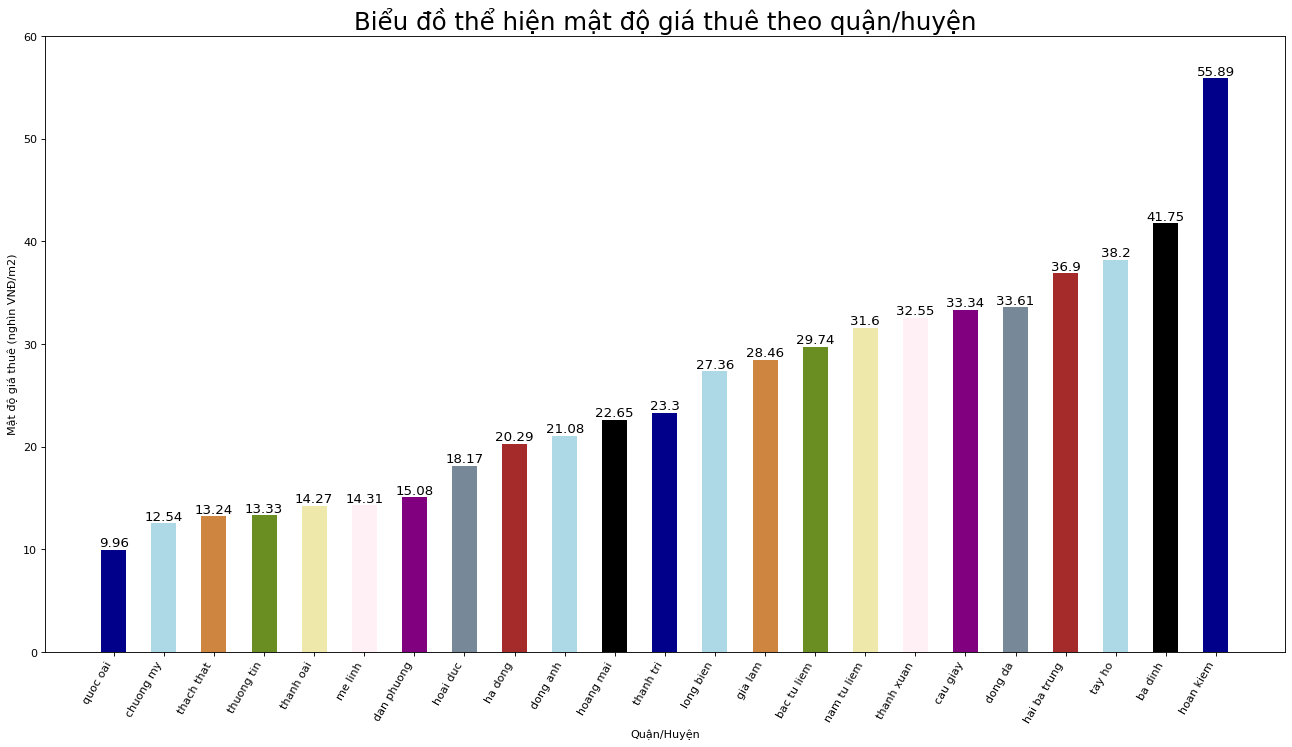

In [132]:
# Code ở đây
df4 = df1.groupby('district').size().reset_index(name='count')
df4['density'] = df1.groupby('district')['density'].mean().round(2).values
df4 = df4.sort_values(by='density', ascending=True)
all_colors = list(plt.cm.colors.cnames.keys())
print(df4.head())

plt.figure(figsize=(20,10), dpi= 80)
plt.bar(x = df4['district'], height = df4['density'], color=c, width=.5)
plt.xlabel('Quận/Huyện')
plt.ylabel('Mật độ giá thuê (nghìn VNĐ/m2)')
plt.ylim(0, 60)
plt.title("Biểu đồ thể hiện mật độ giá thuê theo quận/huyện", fontsize=22)
plt.gca().set_xticklabels(df4['district'], rotation=60, horizontalalignment= 'right')
for i, val in enumerate(df4['density'].values):
    plt.text(i, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

* Giá nhà đất trung bình theo các phường quận Hoàn Kiếm (VND/m2)

            ward    price  square  density
8     ly thai to  1450.00    45.0    34.22
0   chuong duong  1233.33    37.5    37.66
3      dong xuan  2200.00    49.0    39.80
11    trang tien  3325.00    85.0    41.21
5        hang bo  2300.00    50.0    46.00


C:\Users\Thach\AppData\Local\Temp\ipykernel_16008\2298004386.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df5['ward'], rotation=60, horizontalalignment= 'right')


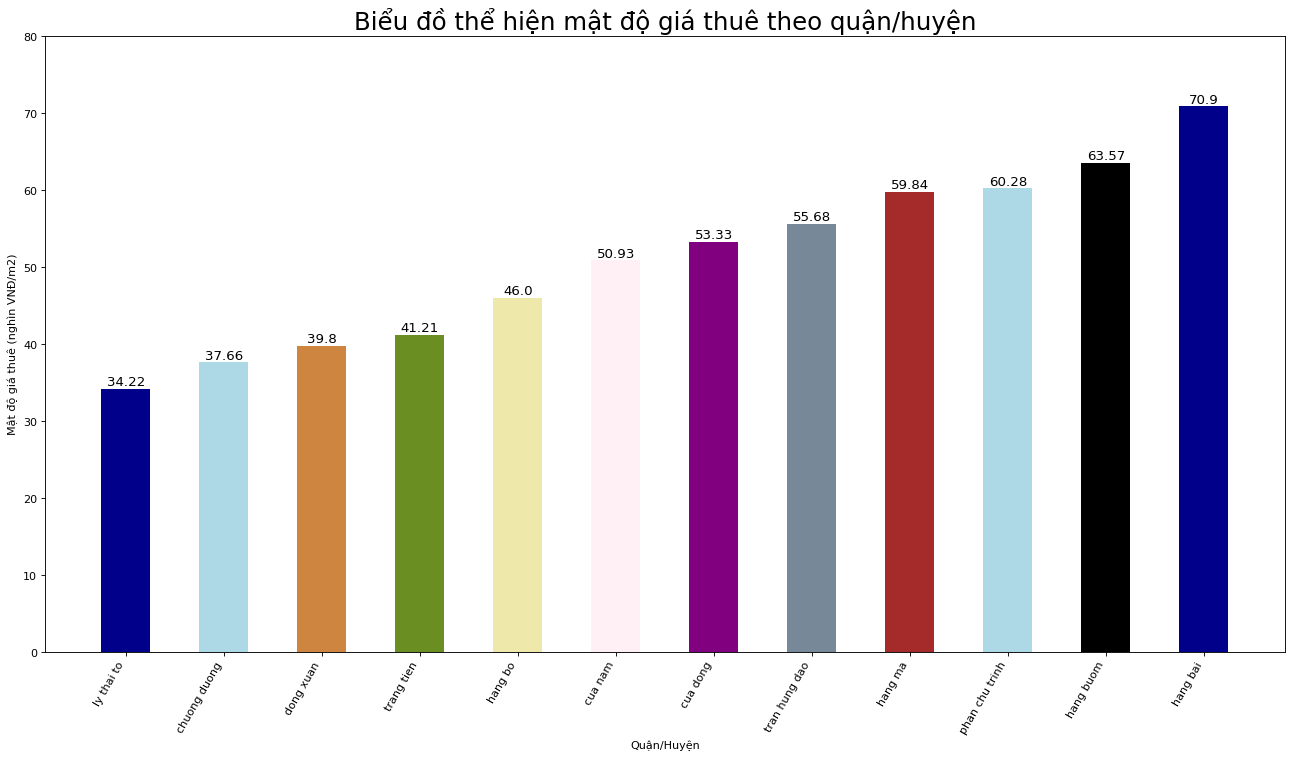

In [131]:
# Code ở đây
df5 = df1[df1['district']=='hoan kiem'][['ward', 'price', 'square', 'density']]
df5 = df5.groupby('ward').mean().round(2).reset_index()
df5 = df5.sort_values(by='density', ascending=True)
all_colors = list(plt.cm.colors.cnames.keys())
print(df5.head())

plt.figure(figsize=(20,10), dpi= 80)
plt.bar(x = df5['ward'], height = df5['density'], color=c, width=.5)
plt.xlabel('Quận/Huyện')
plt.ylabel('Mật độ giá thuê (nghìn VNĐ/m2)')
plt.ylim(0, 80)
plt.title("Biểu đồ thể hiện mật độ giá thuê theo quận/huyện", fontsize=22)
plt.gca().set_xticklabels(df5['ward'], rotation=60, horizontalalignment= 'right')
for i, val in enumerate(df5['density'].values):
    plt.text(i, val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

* Giá nhà đất trung bình theo nhà đầu tư (VND/m2)

In [ ]:
# Code ở đây


* Giá nhà đất trung bình theo dự án (VND/m2)

In [ ]:
# Code ở đây

* Giá bất động sản phân bố theo top 10 nhà đầu tư triệu /m2

In [ ]:
# Code ở đây

* Giá bất động sản phân bố theo dự án

In [ ]:
# Code ở đây

* Giá nhà đất trung bình theo hướng nhà (VND/m2)

In [ ]:
# Code ở đây

In [ ]:
# Code ở đây

3. Tương quan giữa các trường thuộc tính

* https://vi.wikipedia.org/wiki/H%E1%BB%87_s%E1%BB%91_t%C6%B0%C6%A1ng_quan
* bieu do the hien he so tuong quan giua cac cap bien so thuc banggf biểu đồ heatmap

In [ ]:
# Gợi ý: sns.heatmap(cmap='RdYlGn', ...)


* bieu do the hien moi quan he giua cac bien so thuc với biểu đồ phân tán

In [ ]:
#Gợi ý: sns.pairplot(kind='scatter', ...)



4. Mật độ giá nhà trung bình theo quận 

In [ ]:
#Gợi ý: sns.displot()


End :))